In [1]:
import warnings
import textwrap

warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import rioxarray
import fsspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from util.metadata import MetadataIndex

%config InlineBackend.figure_format = 'retina'

In [2]:
# Set up the data collection access
base_url = "https://fs.thielen.science/co_climate/export_20260609/"
index = MetadataIndex(base_url + "geotiff_index.csv")
index.tif_index.head()

,variable_key,geotiff_filepath_lcc_original,geotiff_filepath_wgs84_equirectangular,geotiff_filepath_wgs84_pseudomercator,base_variable,variable_subtype,units,technical_description,symbology_colormap_type,symbology_colormap,symbology_min_value,symbology_max_value,symbology_fixed_value_list
0,wind_metrics_100m_+1.1_CO_ANN_cv_actual_values,lcc_original/cv/wind_metrics_100m_+1.1_CO_ANN_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_ANN_actual_values,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1.0,--
1,wind_metrics_100m_+1.1_CO_DJF_cv_actual_values,lcc_original/cv/wind_metrics_100m_+1.1_CO_DJF_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_DJF_actual_values,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1.0,--
2,wind_metrics_100m_+1.1_CO_JJA_cv_actual_values,lcc_original/cv/wind_metrics_100m_+1.1_CO_JJA_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_JJA_actual_values,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1.0,--
3,wind_metrics_100m_+1.1_CO_MAM_cv_actual_values,lcc_original/cv/wind_metrics_100m_+1.1_CO_MAM_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_MAM_actual_values,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1.0,--
4,wind_metrics_100m_+1.1_CO_SON_cv_actual_values,lcc_original/cv/wind_metrics_100m_+1.1_CO_SON_...,wgs84_equirectangular/cv/wind_metrics_100m_+1....,wgs84_pseudomercator/cv/wind_metrics_100m_+1.1...,cv,+1.1_100m_SON_actual_values,unitless,Coefficient of variation of windspeed at 100m ...,Sequential Speed Light-to-Dark,cmo.speed,0,1.0,--


In [3]:
def region_stats_row(regionstats, current_col, future_col, fmt=lambda x: f'{x:.1f}', display_titles=True, display_legend=True, negative=False, alt_current=False):
    fig, ax = plt.subplots(1,1,figsize=(19,1.75 if display_titles else 1.25))
    
    c_current = "#245D37" if not alt_current else "#24265C"
    c_future = "#FFD100"
    
    x = np.arange(1, 12)
    delta = 0.45
    width = 0.35
    
    rects = ax.bar(x - delta / 2, np.array([regionstats[regionstats['REGION_ID'] == i].iloc[0][current_col] for i in x]), width, label="Today (1.1 °C)" if not alt_current else "Reference Period", color=c_current)
    ax.bar_label(rects, padding=3, fmt=fmt)
    rects = ax.bar(x + delta / 2, np.array([regionstats[regionstats['REGION_ID'] == i].iloc[0][future_col] for i in x]), width, label="2 °C Scenario" if not alt_current else "~2 °C Scenario", color=c_future)
    ax.bar_label(rects, padding=3, fmt=fmt)
    
    if display_titles:
        ax.set_xticks(x, np.array(["\n".join(textwrap.wrap(regionstats[regionstats['REGION_ID'] == i].iloc[0]['REGION_LABEL'], width=12)) for i in x]), fontsize=12)
    else:
        ax.set_xticks([])

    if display_legend:
        ax.legend(ncols=2)
    
    ax.set_xlim([delta, 11 + delta * 1.25])

    if negative:
        ax.spines['bottom'].set_visible(False)
    else:
        ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return fig

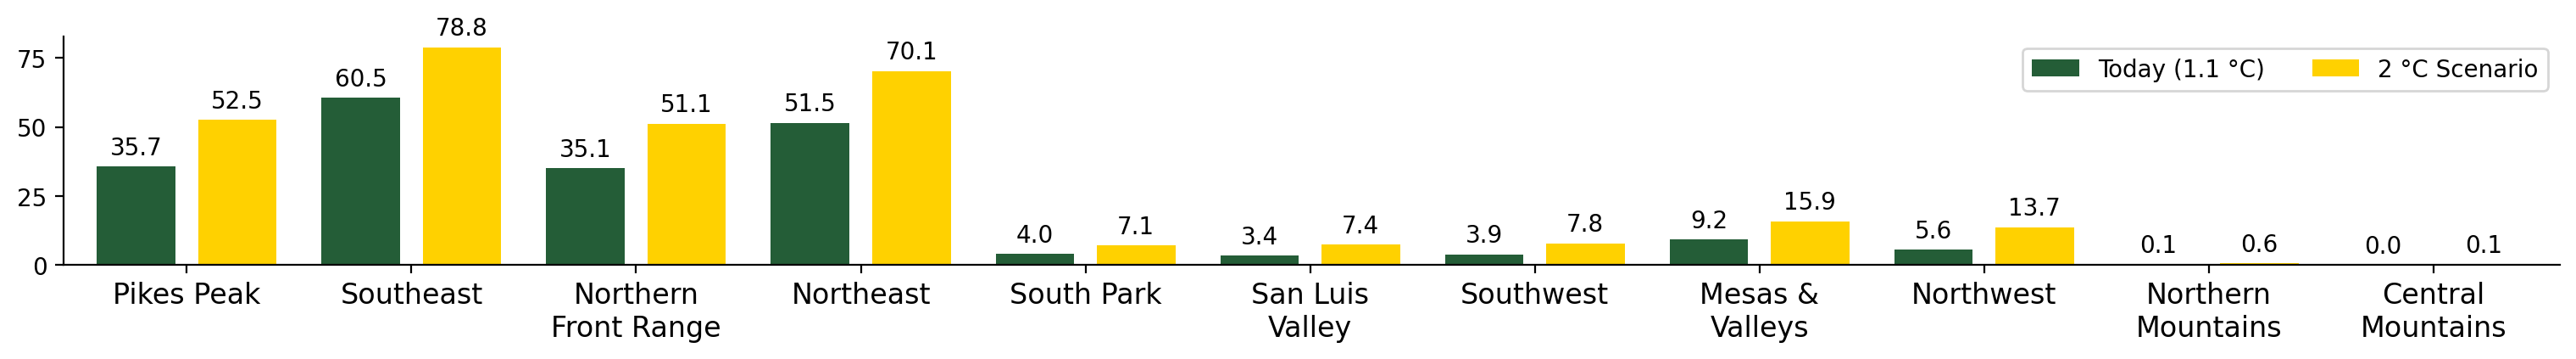

In [4]:
# Example
variable = "TX90F"
current_key = "MEAN_TX90F_GWL11C_actual_values"
future_key = "MEAN_TX90F_GWL20C_actual_values"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key)
plt.show()

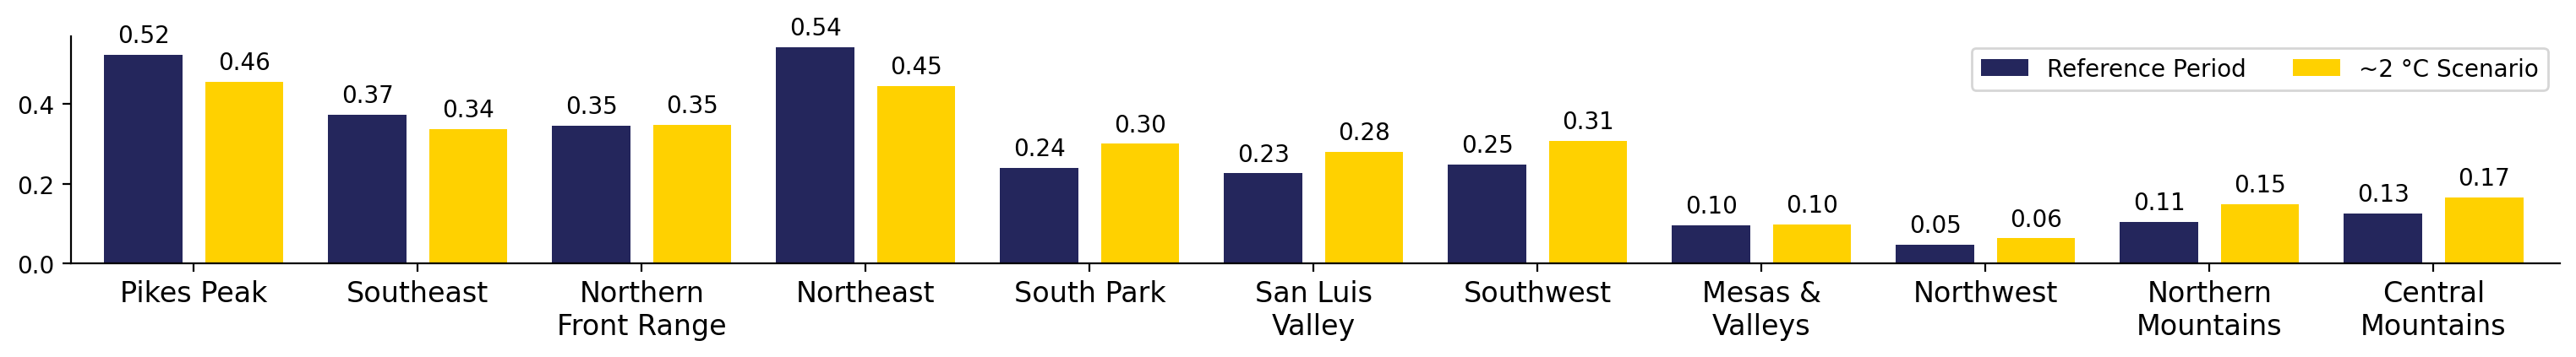

In [5]:
# Example
# HKE
variable = "HKE"
current_key = "MEAN_HKE_annual_REF"
future_key = "MEAN_HKE_annual_PGW"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key, display_legend=True, display_titles=True, alt_current=True, fmt=lambda x: f'{x:.2f}')
plt.show()

---

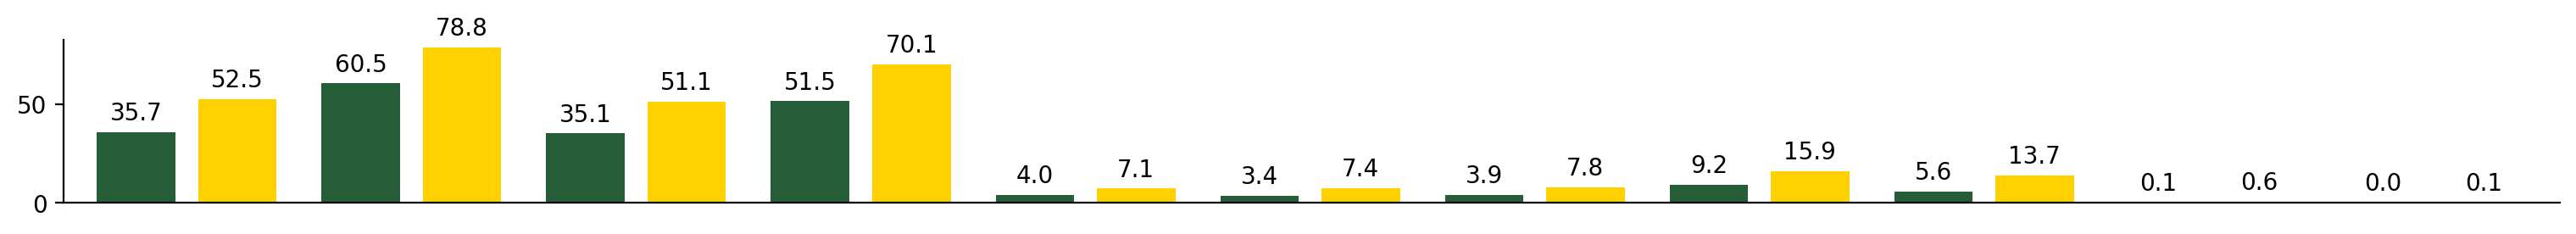

In [6]:
# DAYS ABOVE 90F
variable = "TX90F"
current_key = "MEAN_TX90F_GWL11C_actual_values"
future_key = "MEAN_TX90F_GWL20C_actual_values"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key, display_legend=False, display_titles=False)
plt.show()

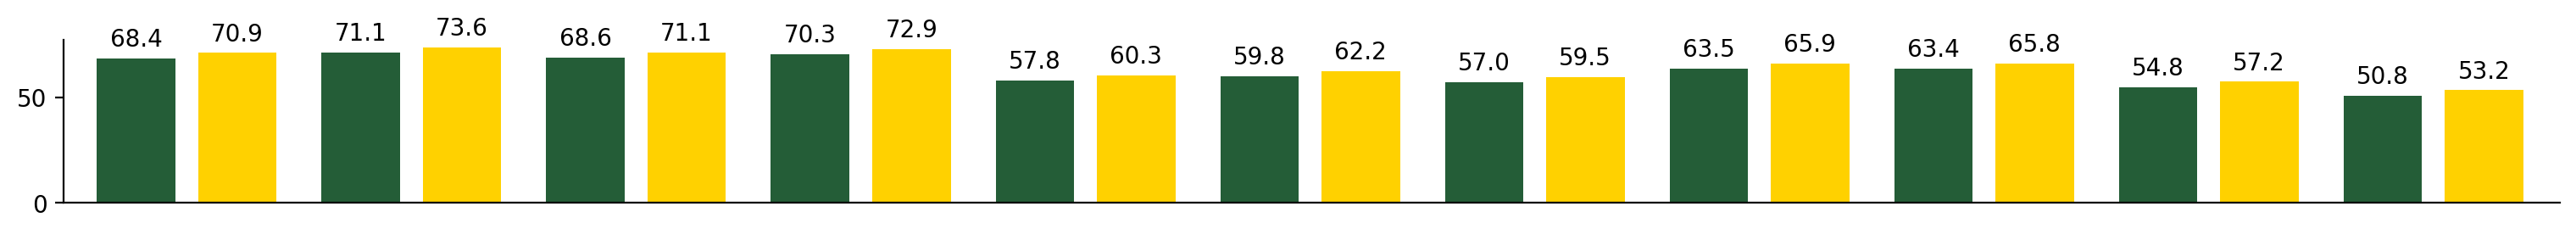

In [7]:
# MAX 5-DAY LOW TEMPERATURE
variable = "TxN5day"
current_key = "MEAN_TxN5day_GWL11C_actual_values"
future_key = "MEAN_TxN5day_GWL20C_actual_values"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key, display_legend=False, display_titles=False)
plt.show()

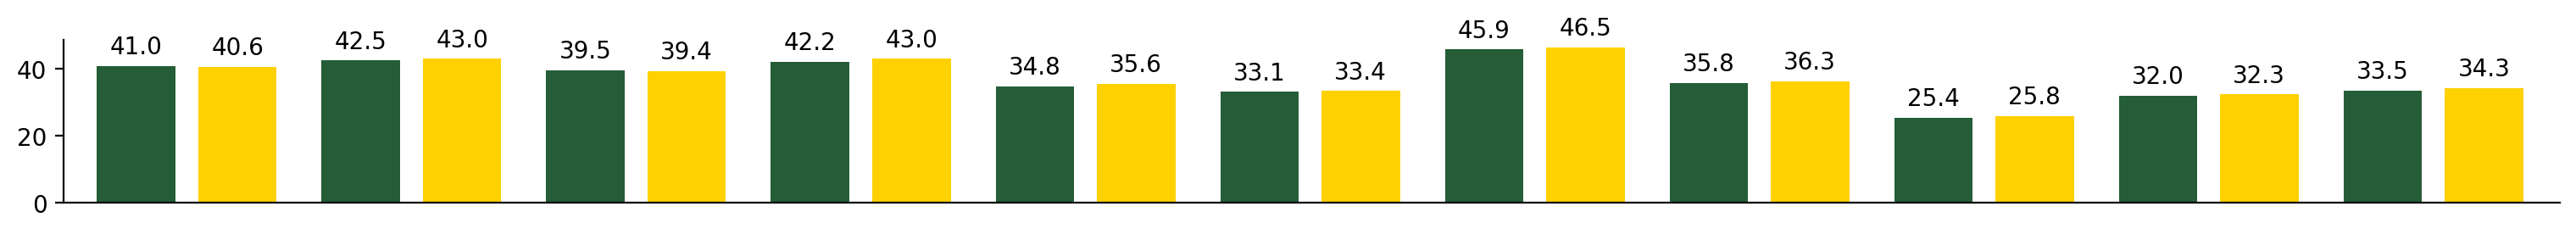

In [8]:
# AVERAGE MAX 1-DAY PRECIP
variable = "Rx1day"
current_key = "MEAN_Rx1day_GWL11C_actual_values"
future_key = "MEAN_Rx1day_GWL20C_actual_values"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key, display_legend=False, display_titles=False)
plt.show()

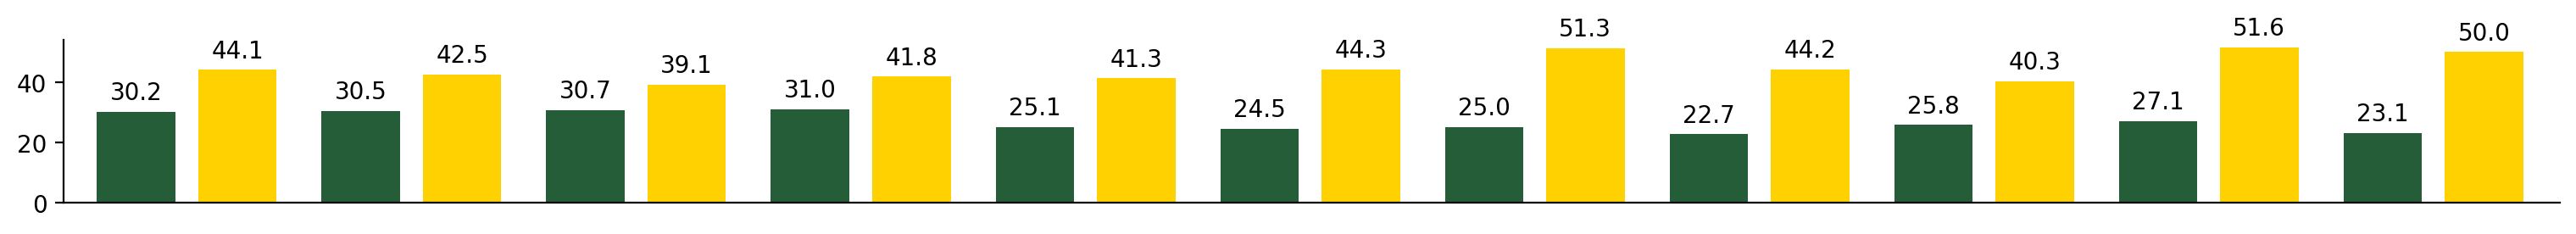

In [9]:
# ARIDITY (d3 days)
variable = "D3_days_Aridity"
current_key = "MEAN_D3_days_Aridity_GWL11C_timescale_12months"
future_key = "MEAN_D3_days_Aridity_GWL20C_timescale_12months"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key, display_legend=False, display_titles=False, fmt=lambda x: f'{x:.1f}')
plt.show()

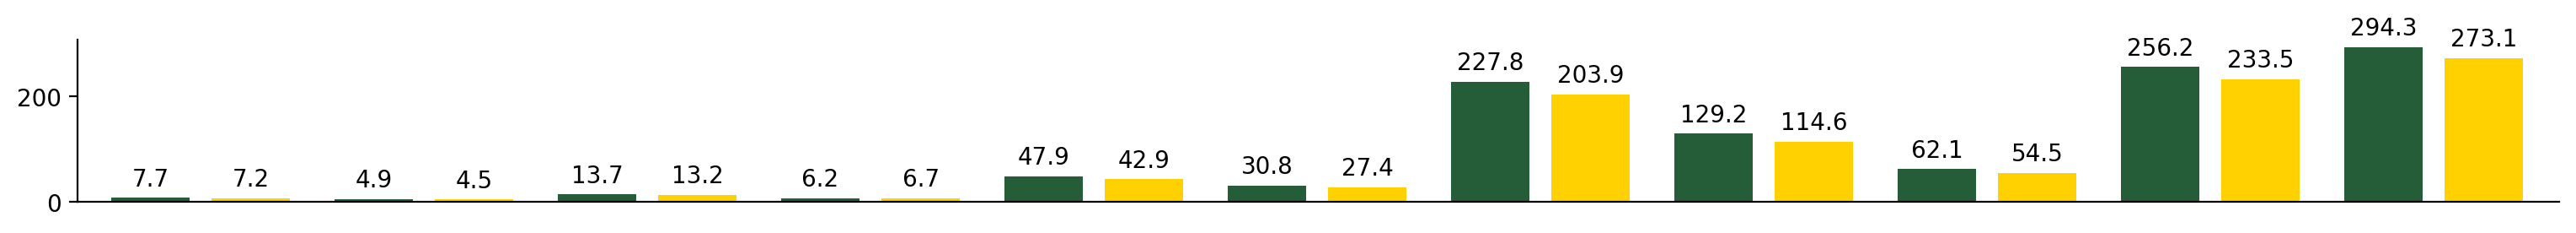

In [10]:
# SWE (wating on update to actual values...)
variable = "SWE"
current_key = "MEAN_SWE_peak_mm_GWL_1.1"
future_key = "MEAN_SWE_peak_mm_GWL_2.0"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
region_stats_row(regionstats, current_key, future_key, display_legend=False, display_titles=False)
plt.show()

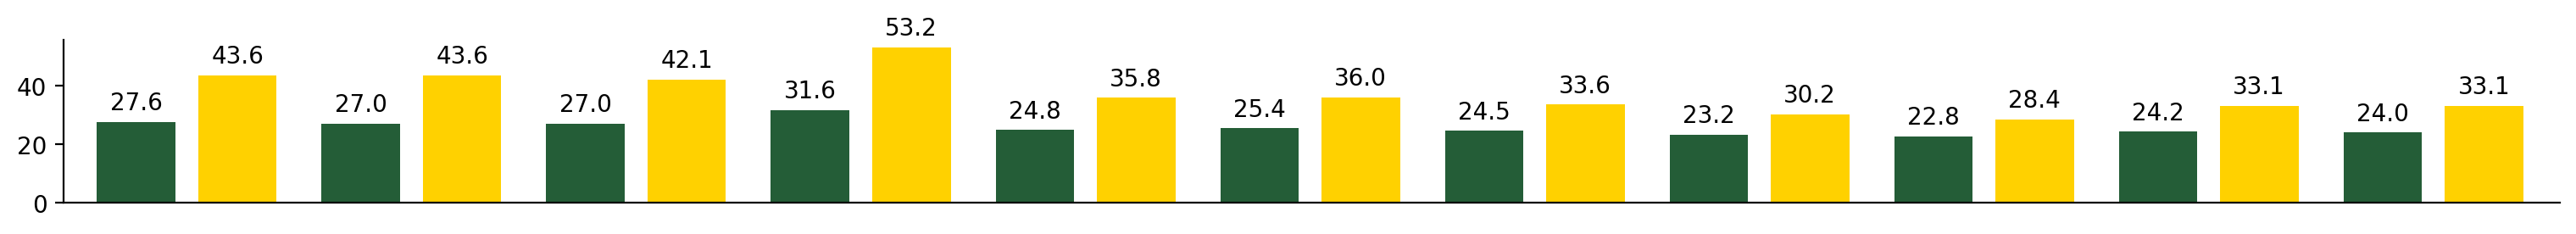

In [11]:
# FWI Exceedance (with normalization to annual / per year!)
variable = "FWI_X95p"
current_key = "MEAN_FWI_X95p_GWL11C_actual_values_normed"
future_key = "MEAN_FWI_X95p_GWL20C_actual_values_normed"
regionstats = gpd.read_file(base_url + f"/climate_region_stats/{variable}.geojson")
regionstats["MEAN_FWI_X95p_GWL11C_actual_values_normed"] = regionstats["MEAN_FWI_X95p_GWL11C_actual_values"] / 28
regionstats["MEAN_FWI_X95p_GWL20C_actual_values_normed"] = regionstats["MEAN_FWI_X95p_GWL20C_actual_values"] / 28
region_stats_row(regionstats, current_key, future_key, display_legend=False, display_titles=False, fmt=lambda x: f'{x:.1f}')
plt.show()